In [170]:
import warnings

warnings.filterwarnings("ignore")

from itertools import groupby

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import spearmanr
from scipy.stats import shapiro

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import textwrap

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

### 1. Получить файл варианта с данными

In [171]:
DATA_PATH = "Вар_42_Б24-215_Гаганидзе_Лаба2_студент.xlsx"
#DATA_PATH = "Вар_46_Б24-215_Кузьмина_Лаба2_студент.xlsx"
df_raw = pd.read_excel(DATA_PATH)
print(f"Размер: {df_raw.shape}")
# print(f"Колонки:\n {"\n".join(list(df_raw.columns))}")
display(df_raw)

Размер: (2500, 26)


,ID,"Среднегодовой доход, тыс. $","Объем потребленного алкоголя в год, л.",Количество членов семьи,Количество лет образования,"Доля от дохода семьи которая тратится на продовольствие, %",Коэффициент Джини сообщества,"Издержки сообщества на окружающую среду, млн. $","Охват беспроводной связи в сообществе, %","Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек",Волатильность потребительских цен в сообществе,Сфера занятости,Оценка благополучия,Оценка социальной поддержки,Ожидаемая продолжительность здоровой жизни,Свобода граждан самостоятельно принимать жизненно важные решения,Индекс Щедрости,Индекс отношения к коррупции,Оценка риска безработицы,Индекс кредитного оптимизма,Индекс страха социальных конфликтов,Индекс семьи,Индекс продовольственной безопасности,Чувство технологического прогресса,Чувство неравенства доходов в обществе,Ощущаемое счастье
0,1,84.091,13.02,6,8,49.0,0.472727,154.49,0.329,15.74,3.50,Корпоративный сектор,67.0,52.0,50.0,59.0,53.0,40.0,51.0,43.0,78.0,18.0,49.0,40.0,43.0,Suffering
1,2,301.312,0.00,3,13,30.0,0.183591,389.61,0.669,4.58,7.00,Неформальная занятость,76.0,70.0,36.0,47.0,71.0,35.0,67.0,57.0,46.0,28.0,70.0,62.0,51.0,Doing well
2,3,275.853,7.46,5,11,42.1,0.383192,284.57,0.658,21.93,5.31,Корпоративный сектор,48.0,72.0,24.0,55.0,59.0,29.0,36.0,46.0,25.0,26.0,48.0,50.0,51.0,Coping
3,4,275.425,0.00,4,17,30.1,0.263366,284.71,0.807,6.37,4.22,Государственная служба,43.0,87.0,59.0,45.0,70.0,45.0,43.0,72.0,40.0,31.0,82.0,69.0,61.0,Doing well
4,5,228.560,8.71,3,13,33.7,0.183591,389.61,0.669,4.58,7.00,Государственная служба,32.0,67.0,48.0,55.0,52.0,53.0,38.0,55.0,46.0,28.0,70.0,51.0,38.0,Coping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,71.486,16.09,4,9,57.5,0.472727,154.49,0.329,15.74,3.50,Неформальная занятость,84.0,51.0,53.0,30.0,37.0,80.0,68.0,22.0,8.0,23.0,52.0,32.0,46.0,Depressed
2496,2497,242.672,1.06,4,12,30.9,0.263366,284.71,0.807,6.37,4.22,Самозанятый,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Неизвестно
2497,2498,60.765,0.00,6,13,57.9,0.834747,0.00,0.359,11.92,0.00,Неформальная занятость,40.0,85.0,38.0,65.0,42.0,64.0,61.0,67.0,33.0,29.0,62.0,56.0,39.0,Thriving
2498,2499,316.403,6.79,4,15,32.8,0.481202,143.32,0.911,0.00,3.43,МСП,80.0,83.0,75.0,70.0,22.0,63.0,49.0,63.0,66.0,21.0,98.0,62.0,46.0,Doing well


In [172]:
df_work = df_raw.drop(columns=["ID"])

grouped_data = [
    (is_numeric, df_work[list(g)])
    for is_numeric, g in groupby(
        df_work.columns, key=lambda c: df_work[c].dtype != "str"
    )
]

for i, (is_numeric, df_group) in enumerate(grouped_data, 1):
    group_type = "Численные" if is_numeric else "Строковые"
    print(f"--- Группа {i} ({group_type}) ---")
    print(*df_group.columns, sep="\n", end="\n\n")

--- Группа 1 (Численные) ---
Среднегодовой доход, тыс. $
Объем потребленного алкоголя в год, л.
Количество членов семьи
Количество лет образования
Доля от дохода семьи которая тратится на продовольствие, %
Коэффициент Джини сообщества
Издержки сообщества на окружающую среду, млн. $
Охват беспроводной связи в сообществе, %
Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
Волатильность потребительских цен в сообществе

--- Группа 2 (Строковые) ---
Сфера занятости

--- Группа 3 (Численные) ---
Оценка благополучия
Оценка социальной поддержки
Ожидаемая продолжительность здоровой жизни
Свобода граждан самостоятельно принимать жизненно важные решения
Индекс Щедрости
Индекс отношения к коррупции
Оценка риска безработицы
Индекс кредитного оптимизма
Индекс страха социальных конфликтов
Индекс семьи
Индекс продовольственной безопасности
Чувство технологического прогресса
Чувство неравенства доходов в обществе

--- Группа 4 (Строковые) ---
Ощущаемое счастье



### 2. Открыть набор данных и выделить группы признаков: причины, состояния, целевая переменная

In [173]:
# Полный ординальный порядок меток (от худшего к лучшему).
# 'Strugglng' — опечатка в исходных данных, оставляем как есть.
CANTRIL_ORDER = [
    "Hopeless",
    "Depressed",
    "Suffering",
    "Strugglng",
    "Coping",
    "Just ok",
    "Doing well",
    "Blooming",
    "Thriving",
    "Prospering",
]

CANTRIL_COL = df_raw.columns[-1] # "Ощущаемое счастье"
MARKER_UNKNOWN = "Неизвестно" # метка «неизвестно» в этой колонке

ALL_CAUSE, STATE_FEATURES = [
    list(g.columns) for is_numeric, g in grouped_data if is_numeric
]


CAT_FEATURES = [
    col for is_numeric, g in grouped_data
    if not is_numeric and CANTRIL_COL not in g.columns
    for col in g.columns
]

SIGNIFICANCE_THRESHOLD = 0.1  # порог |ρ| для отбора признаков состояния
VIF_THRESHOLD = 5.0
PVALUE_THRESHOLD = 0.05
RHO_THRESHOLD = 0.2
R2_THRESHOLD = 0.45
DELTA_THRESHOLD = 0.04
BETA_THRESHOLD = 0.1

### 3. Выделить наблюдения с известным и неизвестным значением счастья

In [174]:
is_unknown = (df_raw[CANTRIL_COL].str.strip() == MARKER_UNKNOWN) | \
    (df_raw[CANTRIL_COL].isna())

df_known = df_raw[~is_unknown].copy()
df_unknown = df_raw[is_unknown].copy()

print(f"Известных записей:   {len(df_known)}")
print(f"Неизвестных записей: {len(df_unknown)}")

actual_classes = [c for c in CANTRIL_ORDER if c in df_known[CANTRIL_COL].unique()]

df_known["rank"] = pd.Categorical(
    df_known[CANTRIL_COL], categories=actual_classes, ordered=True
).codes

print("Кодировка классов:")
for rank, cls in enumerate(actual_classes):
    print(f"  {rank:>2}: {cls}")

Известных записей:   1900
Неизвестных записей: 600
Кодировка классов:
   0: Hopeless
   1: Depressed
   2: Suffering
   3: Strugglng
   4: Coping
   5: Just ok
   6: Doing well
   7: Blooming
   8: Thriving
   9: Prospering


### 4. Провести первичный анализ данных (описательные статистики, визуализация, проверка пропусков)


Пропусков в неизвестных данных:
Оценка благополучия                                                 600
Оценка социальной поддержки                                         600
Ожидаемая продолжительность здоровой жизни                          600
Свобода граждан самостоятельно принимать жизненно важные решения    600
Индекс Щедрости                                                     600
Индекс отношения к коррупции                                        600
Оценка риска безработицы                                            600
Индекс кредитного оптимизма                                         600
Индекс страха социальных конфликтов                                 600
Индекс семьи                                                        600
Индекс продовольственной безопасности                               600
Чувство технологического прогресса                                  600
Чувство неравенства доходов в обществе                              600
dtype: int64




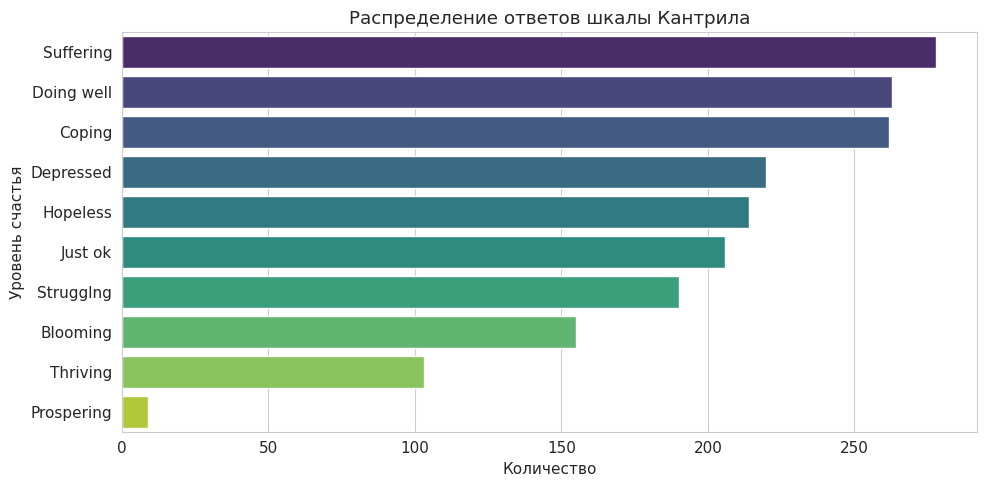

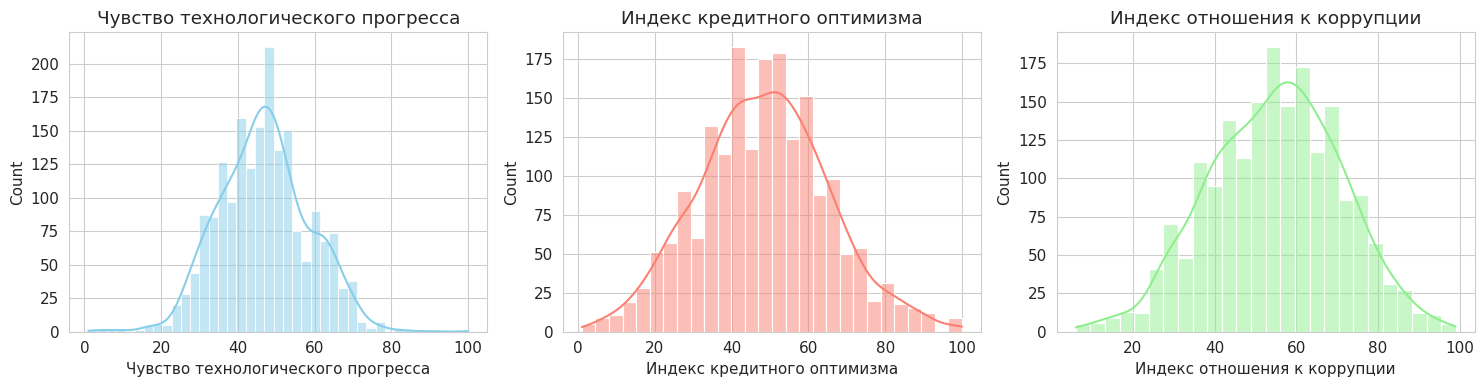

In [175]:
# 1. Проверка пропусков
print("\nПропусков в неизвестных данных:")
missing_info = df_raw.isna().sum()
missing_info = missing_info[missing_info > 0]
if missing_info.empty:
    print("Пропусков нет!\n")
else:
    print(missing_info)
    print("\n")

# 2. Описательные статистики числовых признаков
#print("Описательные числовые статистики:")
#display(df_raw.describe().round(2).T)

# 3. Визуализация распределения целевой переменной
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_known,
    y=CANTRIL_COL,
    order=df_known[CANTRIL_COL].value_counts().index,
    palette="viridis",
)
plt.title("Распределение ответов шкалы Кантрила")
plt.xlabel("Количество")
plt.ylabel("Уровень счастья")
plt.tight_layout()
plt.show()

# 5. Визуализация некоторых числовых признаков (гистограммы состояния)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(
    df_raw["Чувство технологического прогресса"],
    kde=True,
    ax=axes[0],
    color="skyblue",
)
axes[0].set_title("Чувство технологического прогресса")

sns.histplot(
    df_raw["Индекс кредитного оптимизма"],
    kde=True,
    ax=axes[1],
    color="salmon"
)
axes[1].set_title("Индекс кредитного оптимизма")

sns.histplot(
    df_raw["Индекс отношения к коррупции"],
    kde=True,
    ax=axes[2],
    color="lightgreen",
)
axes[2].set_title("Индекс отношения к коррупции")

plt.tight_layout()
plt.show()

### 5. Исследовать влияние признаков причины на признаки состояния (корреляционный анализ, линейные регрессии)

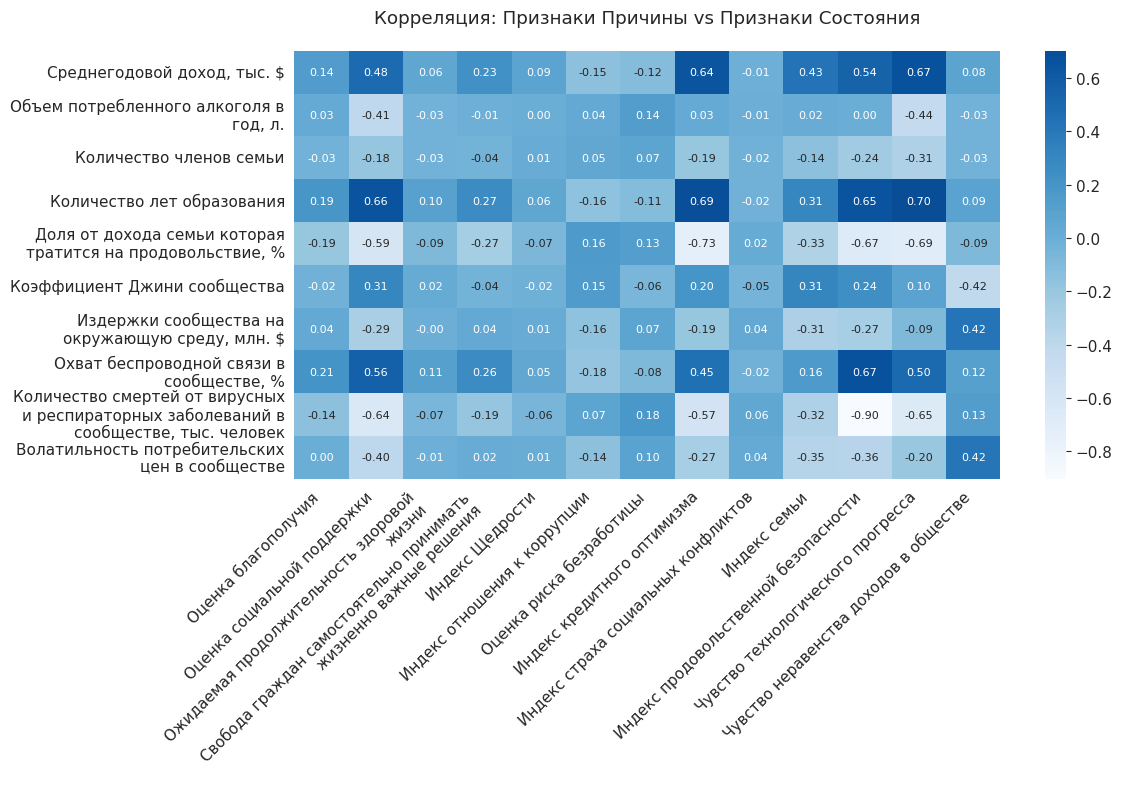

In [176]:
plt.figure(figsize=(12, 8))

cause_state_corr = (
    df_known[ALL_CAUSE + STATE_FEATURES]
    .corr(method="spearman")
    .loc[ALL_CAUSE, STATE_FEATURES]
)

wrapped_y_labels = [textwrap.fill(label, 30) for label in cause_state_corr.index]
wrapped_x_labels = [textwrap.fill(label, 40) for label in cause_state_corr.columns]

sns.heatmap(
    cause_state_corr,
    cmap="Blues",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    yticklabels=wrapped_y_labels,
    xticklabels=wrapped_x_labels,
)
plt.title("Корреляция: Признаки Причины vs Признаки Состояния", pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [177]:
# 1. ЕДИНЫЙ СПЛИТ ДАННЫХ ДЛЯ ВСЕЙ ЛАБОРАТОРНОЙ 
df_train, df_test = train_test_split(
    df_known,
    test_size=0.25,
    random_state=42,
    stratify=df_known["rank"]
)

# 2. Функция VIF только для тренировочных данных
def compute_vif_train(X_df):
    X_const = sm.add_constant(X_df.dropna())
    vif_vals = [variance_inflation_factor(X_const.values, i) for i in range(1, X_const.shape[1])]
    return pd.DataFrame({"Признак": X_df.columns, "VIF": vif_vals}).sort_values("VIF", ascending=False)

# Считаем VIF ТОЛЬКО по Причинам на train
current_cols = ALL_CAUSE
while True:
    vif_res = compute_vif_train(df_train[current_cols])
    worst = vif_res.iloc[0]
    if worst["VIF"] <= VIF_THRESHOLD:
        break
    current_cols.remove(worst["Признак"])

print("Итоговые колонки после VIF (Причины):", *current_cols, sep="\n", end="\n\n")

Итоговые колонки после VIF (Причины):
Среднегодовой доход, тыс. $
Объем потребленного алкоголя в год, л.
Количество членов семьи
Количество лет образования
Доля от дохода семьи которая тратится на продовольствие, %
Коэффициент Джини сообщества
Охват беспроводной связи в сообществе, %
Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек



In [178]:
# 3. ПОСТРОЕНИЕ ДВУХШАГОВЫХ МОДЕЛЕЙ ДЛЯ "СОСТОЯНИЙ" СО ШТРАФОВАНИЕМ ОСТАТКОВ
# Словарь для сохранения моделей (будет использоваться в build_X и шагах предсказания)
ols_state_models_full = {} 

for state_col in STATE_FEATURES:
    # Берем строго тренировочный датасет df_train
    valid_data = df_train.dropna(subset=[state_col] + current_cols)
    y_target = valid_data[state_col]
    X_features = sm.add_constant(valid_data[current_cols])

    # Шаг А: Строим базовую OLS для проверки предпосылок
    base_model = sm.OLS(y_target, X_features).fit()
    
    # Проверяем остатки базовой OLS на нормальность
    shapiro_p = stats.shapiro(base_model.resid)[1]
    
    print("=" * 90)
    print(f"Признак состояния: '{state_col}'")
    print(f"Тест Шапиро-Уилка базовой OLS (p-value): {shapiro_p:.5f}")

    # Шаг Б: Если остатки не нормальны, применяем робастный штраф Хьюбера (RLM)
    if shapiro_p < 0.05:
        print("  → Нарушена нормальность остатков. Применяем штраф Хьюбера через RLM...")
        model = sm.RLM(y_target, X_features, M=sm.robust.norms.HuberT()).fit()
        is_robust = True
        
        # --- АНАЛИЗ АНОМАЛЬНОЙ СТРАТЫ ---
        # Изолируем 2-сигма аномалии базовой OLS, которые заставили применить штраф
        residuals_series = pd.Series(base_model.resid, index=valid_data.index)
        threshold = 2 * residuals_series.std()
        print(threshold)
        anomalies = valid_data[abs(residuals_series) > threshold]
        
        print(f"  → Выявлено крупных аномалий (выбросов): {len(anomalies)}")
        #display(anomalies[[state_col] + current_cols].head(), end="\n\n")
        for cat_col in CAT_FEATURES:
            train_dist = valid_data[cat_col].value_counts(normalize=True)
            anom_dist = anomalies[cat_col].value_counts(normalize=True) if not anomalies.empty else pd.Series()
            
            # Безопасное вычитание долей без генерации NaN
            diff = anom_dist.sub(train_dist, fill_value=0)
            
            for category, delta in diff.items():
                if abs(delta) > DELTA_THRESHOLD:
                    direction = "ЧАЩЕ" if delta > 0 else "РЕЖЕ"
                    print(f"    * Страта '{category}' ({cat_col}) встречается в аномалиях {direction} (Δ = {delta:+.3f})")
    else:
        print("  → Остатки распределены нормально. Оставляем классический OLS.")
        model = base_model
        is_robust = False

    # Шаг В: Универсальный расчёт p-value, стандартизированных Beta и псевдо-R²
    # Считаем псевдо-R² как квадрат корреляции Пирсона между фактом и прогнозом
    preds = model.predict(X_features)
    r2_value = stats.pearsonr(y_target, preds)[0] ** 2
    
    # Стандартные отклонения для расчета Beta-коэффициентов
    std_y = y_target.std()
    std_X = X_features.std()

    print(f"\nЗначимые факторы для '{state_col}' (R² = {r2_value:.3f}, Huber Штраф: {is_robust}):")
    
    # Извлекаем t/z-статистики
    t_stats = model.tvalues.drop("const").abs()
    
    for cause_name, t_val in t_stats.items():
        coef = model.params[cause_name]
        
        # Для OLS берем pvalues, для RLM вычисляем p-value из z-метрик через нормальное распределение
        if is_robust:
            p_val = 2 * (1 - stats.norm.cdf(abs(t_val)))
        else:
            p_val = model.pvalues[cause_name]

        # Вычисляем стандартизированный Beta-коэффициент
        beta_coef = coef * (std_X[cause_name] / std_y)

        # Выводим только сильные и статистически значимые связи
        if p_val < PVALUE_THRESHOLD and abs(beta_coef) >= BETA_THRESHOLD:
            print(f"\t• {cause_name}")
            print(f"\t  Направление: {'прямое' if coef > 0 else 'обратное'} (p={p_val:.4f}, Beta={beta_coef:+.3f})")

    # Сохраняем готовую модель в словарь под именем ols_models
    # Это имя используется далее по вашему коду в цикле восстановления df_unknown и функции build_X!
    ols_state_models_full[state_col] = {
        "model": model, 
        "rsquared": r2_value,
        "is_robust": is_robust
    }
print("\n" + "="*90 + "\nВсе модели успешно обучены и сохранены в словарь ols_state_models_full.")

Признак состояния: 'Оценка благополучия'
Тест Шапиро-Уилка базовой OLS (p-value): 0.54915
  → Остатки распределены нормально. Оставляем классический OLS.

Значимые факторы для 'Оценка благополучия' (R² = 0.047, Huber Штраф: False):
	• Охват беспроводной связи в сообществе, %
	  Направление: прямое (p=0.0053, Beta=+0.112)
Признак состояния: 'Оценка социальной поддержки'
Тест Шапиро-Уилка базовой OLS (p-value): 0.82830
  → Остатки распределены нормально. Оставляем классический OLS.

Значимые факторы для 'Оценка социальной поддержки' (R² = 0.917, Huber Штраф: False):
	• Объем потребленного алкоголя в год, л.
	  Направление: обратное (p=0.0000, Beta=-0.526)
	• Количество лет образования
	  Направление: прямое (p=0.0000, Beta=+0.416)
	• Коэффициент Джини сообщества
	  Направление: прямое (p=0.0000, Beta=+0.386)
	• Охват беспроводной связи в сообществе, %
	  Направление: прямое (p=0.0000, Beta=+0.333)
Признак состояния: 'Ожидаемая продолжительность здоровой жизни'
Тест Шапиро-Уилка базовой O

In [179]:
print("=== АВТОМАТИЧЕСКИЙ АНАЛИЗ СКРЫТЫХ ЧИСЛОВЫХ СТРАТ ===")

DELTA_THRESHOLD = 0.04  # Порог существенного отклонения (4%)

# Перебираем все обученные модели из вашего словаря
for state_col, model_info in ols_state_models_full.items():
    
    # Запускаем анализ СТРОГО там, где была нарушена нормальность (is_robust == True)
    if model_info["is_robust"]:
        
        # Выделяем валидные данные для текущего состояния
        valid_data = df_train.dropna(subset=[state_col] + current_cols)
        
        # Строим базовый МНК, чтобы вытащить исходные (неоштрафованные) остатки
        base_ols = sm.OLS(valid_data[state_col], sm.add_constant(valid_data[current_cols])).fit()
        anomalies_mask = abs(base_ols.resid) > (2 * base_ols.resid.std())
        
        print(f"\n" + "="*80)
        print(f"ПРИЗНАК СОСТОЯНИЯ: '{state_col}' (Выявлено аномалий: {anomalies_mask.sum()})")
        print("="*80)
        
        # Проверяем каждый числовой фактор на предмет скрытых слоев (страт)
        for col in current_cols:
            try:
                # Разбиваем числовой фактор на терцили (3 равные группы)
                strata = pd.qcut(valid_data[col], q=3, labels=['Низкий', 'Средний', 'Высокий'], duplicates='drop')
            except Exception:
                continue
            
            # Считаем разницу долей: (Доля в аномалиях) - (Доля в датасете)
            diff = strata[anomalies_mask].value_counts(normalize=True).sub(strata.value_counts(normalize=True), fill_value=0)
            
            has_output = False
            for strata_name, delta in diff.items():
                if abs(delta) > DELTA_THRESHOLD:
                    if not has_output:
                        print(f"  Фактор: {col}")
                        has_output = True
                    direction = "ЧАЩЕ" if delta > 0 else "РЕЖЕ"
                    print(f"    → Страта '{strata_name} уровень' встречается в аномалиях {direction} (Δ = {delta:+.3f})")

=== АВТОМАТИЧЕСКИЙ АНАЛИЗ СКРЫТЫХ ЧИСЛОВЫХ СТРАТ ===

ПРИЗНАК СОСТОЯНИЯ: 'Индекс отношения к коррупции' (Выявлено аномалий: 68)
  Фактор: Среднегодовой доход, тыс. $
    → Страта 'Высокий уровень' встречается в аномалиях ЧАЩЕ (Δ = +0.049)
  Фактор: Объем потребленного алкоголя в год, л.
    → Страта 'Низкий уровень' встречается в аномалиях ЧАЩЕ (Δ = +0.049)
    → Страта 'Высокий уровень' встречается в аномалиях РЕЖЕ (Δ = -0.053)
  Фактор: Количество членов семьи
    → Страта 'Средний уровень' встречается в аномалиях ЧАЩЕ (Δ = +0.072)
  Фактор: Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
    → Страта 'Высокий уровень' встречается в аномалиях РЕЖЕ (Δ = -0.058)

ПРИЗНАК СОСТОЯНИЯ: 'Индекс семьи' (Выявлено аномалий: 60)
  Фактор: Среднегодовой доход, тыс. $
    → Страта 'Низкий уровень' встречается в аномалиях РЕЖЕ (Δ = -0.067)
    → Страта 'Средний уровень' встречается в аномалиях РЕЖЕ (Δ = -0.050)
    → Страта 'Высокий уровень' встречается в аном

### 1. Индекс отношения к коррупции (Выявлено аномалий: 68)
Здесь перекосы относительно небольшие ($\Delta \approx 5-7\%$), но они системны. Линейная модель хуже всего предсказывает отношение к коррупции у граждан с:
1. Высоким доходом. (Δ = +0.049)
2. Низким уровнем потребления алкоголя. (Δ = +0.049)
3. Семьям среднего размера. (Δ = +0.072)

Кластер таких людей описывает *Upper class*.

### 2. Индекс семьи (Выявлено аномалий: 60)
Здесь МНК столкнулся с серьезной проблемой. Обратите внимание на профиль людей, которые чаще всего улетают в выбросы ($\Delta > 0$):
1. Высокий уровень дохода ($\Delta = +0.117$)
2. Высокий уровень количества членов семьи ($\Delta = +0.084$)
3. Средний уровень образования ($\Delta = +0.165$)
4. Низкий уровень трат на еду ($\Delta = +0.149$)
5. Средний охват беспроводной связи ($\Delta = +0.192$)

Можно сказать, что люди из этих страт приверженцы *Upper-Middle Class*.

### 3. Чувство технологического прогресса (Выявлено аномалий: 60)
Здесь произошел самый мощный методологический провал МНК. Дельты запредельные ($\Delta > 30-40\%$). Посмотрите на этот профиль аномалий:
1. Низкий уровень дохода ($\Delta = +0.267$)
2. Высокий уровень потребления алкоголя ($\Delta = +0.417$ — колоссальный перекос!)
3. Низкий уровень образования ($\Delta = +0.126$)
4. Высокий уровень трат на продовольствие ($\Delta = +0.285$)
5. Низкий коэффициент Джини ($\Delta = +0.332$)
6. Высокий уровень смертности от респираторных заболеваний ($\Delta = +0.357$)

Видно, что описать кластер людей можно как *Low class*.

### Выводы по этапу стратификационного анализа остатков

Проведенный анализ выявил, что нарушения нормальности остатков (зафиксированные тестом Шапиро-Уилка на этапе классического МНК) носят не случайный (стохастический), а выраженный **социально-экономический характер**. Квантование непрерывных признаков на терцили позволило локализовать группы, на которых линейная модель теряет предсказательную силу:

1. **"Индекс отношения к коррупции":** модель нестабильна на подгруппах с высокими доходами и низким потреблением алкоголя.
2. **"Индекс семьи":** зафиксирован методологический излом на представителях условного "верхнего и верхнего-среднего класса" (крупные обеспеченные семьи с минимальной долей расходов на питание).
3. **"Чувство технологического прогресса":** обнаружена критическая гетероскедастичность. Ядром аномалий МНК стали наиболее уязвимые и депрессивные страты (низкий доход, низкое образование, экстремально высокое потребление алкоголя ($\Delta = +41.7\%$) и высокая локальная смертность ($\Delta = +35.7\%$)). 

**Итоговое методологическое решение:**
Поскольку выбросы оказались жестко привязаны к конкретным социальным стратам, их механическое удаление привело бы к потере важнейших сегментов выборки и смещению выводов (*selection bias*). Переход к **робастной линейной регрессии (RLM) с функцией штрафования Хьюбера** является единственно верным решением: алгоритм в процессе итераций автоматически снизил веса (оштрафовал остатки) данных страт, защитив глобальные коэффициенты модели от смещения.

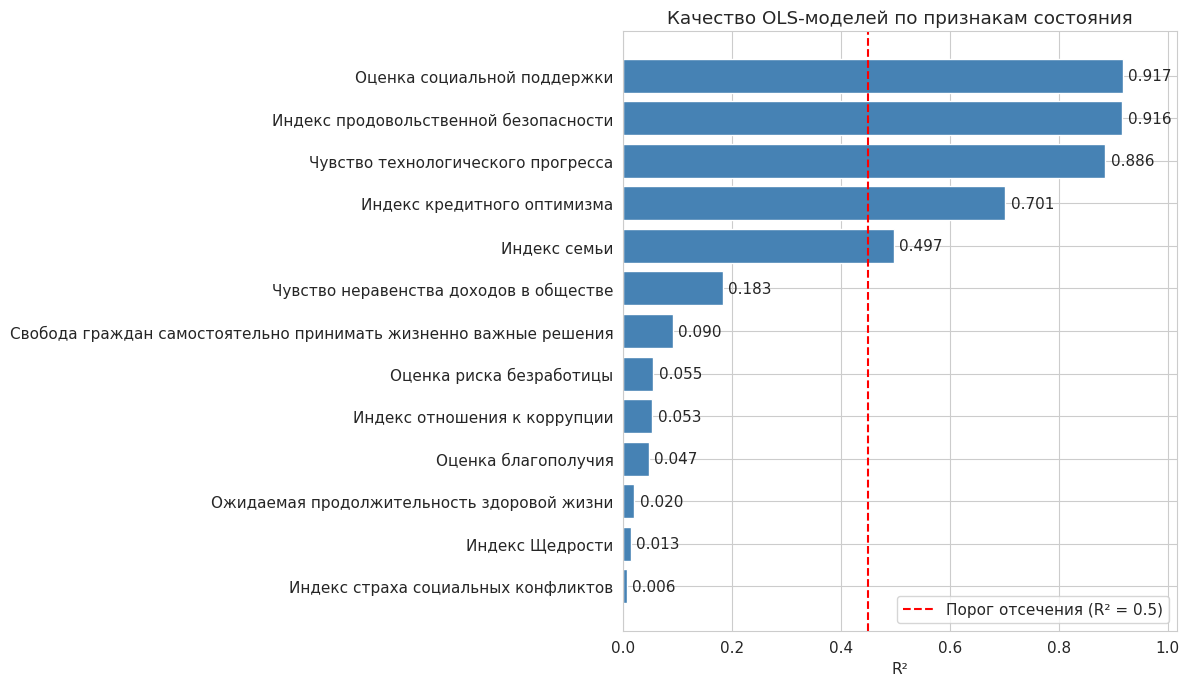

In [180]:
actual_states = [s for s in STATE_FEATURES if s in ols_state_models_full]

rsquared_df = pd.DataFrame(
    {
        "Признак состояния": actual_states,
        "R²": [ols_state_models_full[s]["rsquared"] for s in actual_states],
    }
).sort_values("R²", ascending=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    rsquared_df["Признак состояния"], rsquared_df["R²"], color="steelblue"
)
plt.xlabel("R²")
plt.title("Качество OLS-моделей по признакам состояния")

for bar, val in zip(bars, rsquared_df["R²"]):
    plt.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
    )
plt.axvline(x=R2_THRESHOLD, color='red', linestyle='--', label='Порог отсечения (R² = 0.5)')
plt.legend(loc='lower right')
plt.xlim(0, max(rsquared_df["R²"]) + 0.1)
plt.tight_layout()
plt.show()

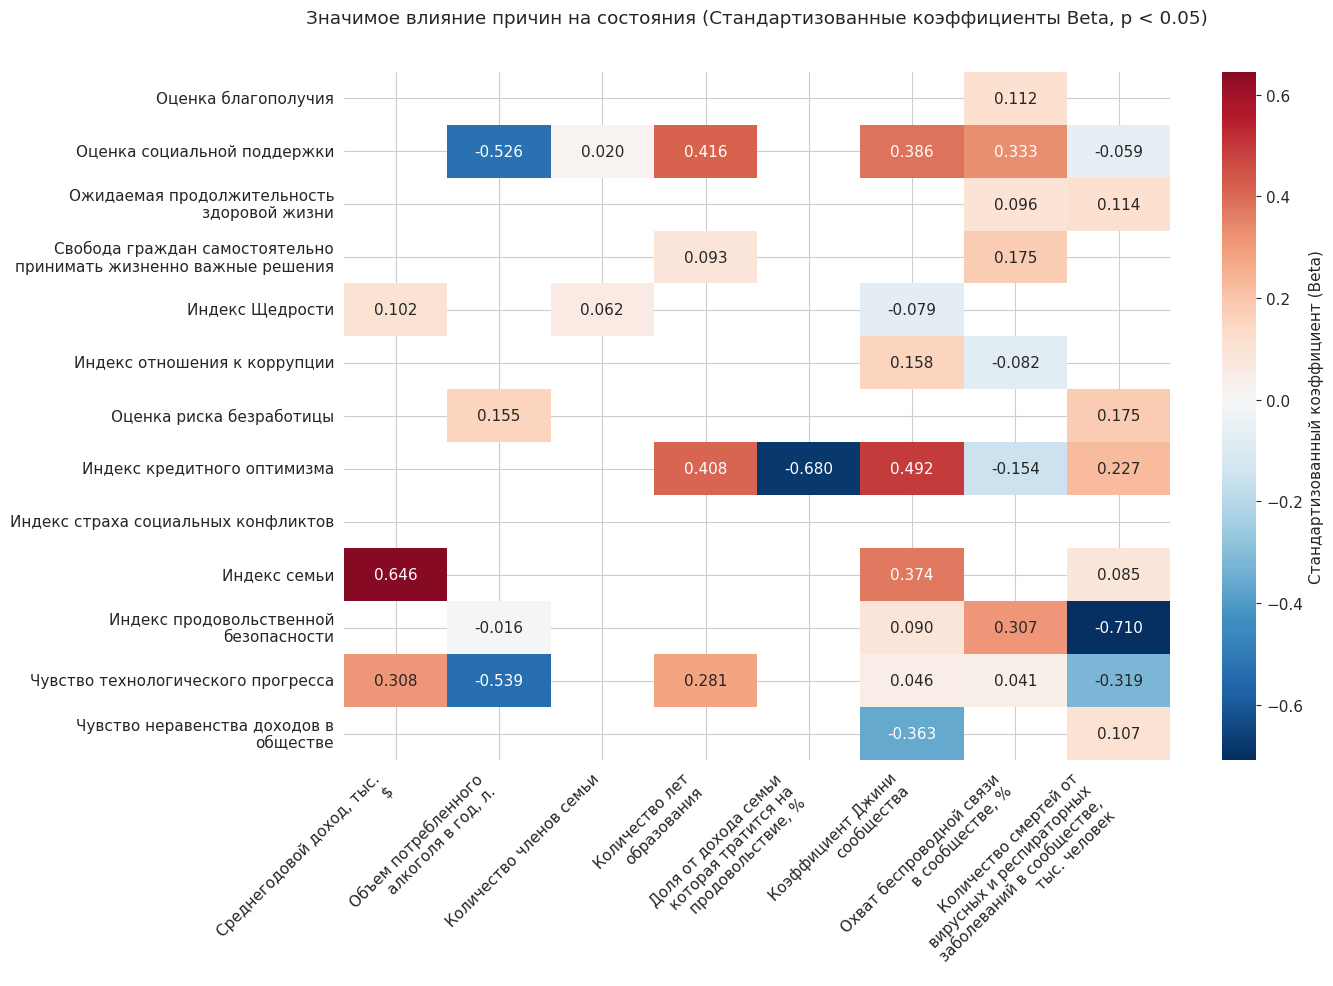

In [181]:
p_val_matrix = pd.DataFrame()
coef_matrix = pd.DataFrame()

# Итерируемся по словарю моделей (внутри лежат словари с моделью и флагом робастности)
for state, model_info in ols_state_models_full.items():
    # Распаковываем объект модели и флаг, применялся ли робастный штраф
    model = model_info["model"]
    is_robust = model_info["is_robust"]
    
    # 1. Безопасный сбор p-value без константы
    t_stats = model.tvalues.drop("const")
    if is_robust:
        # Для RLM (штраф Хьюбера) считаем двустороннее p-value из z-статистик
        p_values = 2 * (1 - stats.norm.cdf(t_stats.abs()))
        p_val_matrix[state] = pd.Series(p_values, index=t_stats.index)
    else:
        # Для обычной OLS берем стандартный атрибут
        p_val_matrix[state] = model.pvalues.drop("const")

    # 2. Считаем СТАНДАРТИЗОВАННЫЕ коэффициенты (Beta) по тренировочным данным
    valid_data = df_train.dropna(subset=[state] + current_cols)
    std_x = valid_data[current_cols].std()
    std_y = valid_data[state].std()

    std_coefs = model.params.drop("const") * (std_x / std_y)
    coef_matrix[state] = std_coefs

# Транспонируем (состояния - строки, причины - столбцы)
p_val_matrix = p_val_matrix.T
coef_matrix = coef_matrix.T

# Создаем матрицу-маску: оставляем коэффициенты ТОЛЬКО там, где p < PVALUE_THRESHOLD
significant_coefs = coef_matrix.mask(p_val_matrix >= PVALUE_THRESHOLD)

# СТРОИМ ОРИГИНАЛЬНЫЙ ГРАФИК (ТИП И СТИЛИСТИКА ПОЛНОСТЬЮ СОХРАНЕНЫ)
plt.figure(figsize=(14, 10))
sns.heatmap(
    significant_coefs,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    xticklabels=[textwrap.fill(c, 25) for c in significant_coefs.columns],
    yticklabels=[textwrap.fill(c, 35) for c in significant_coefs.index],
    cbar_kws={"label": "Стандартизованный коэффициент (Beta)"},
)

plt.title(
    "Значимое влияние причин на состояния (Стандартизованные коэффициенты Beta, p < 0.05)\n",
    pad=20,
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6. Проверить влияние категориальных факторов на признаки состояния (например, сфера занятости; ANOVA, тест Манна—Уитни)

In [182]:
for cat_feature in CAT_FEATURES:
    groups = df_known[cat_feature].dropna().unique()
    print(
        f"Влияние категориального фактора '{cat_feature}' на признаки состояния\n"
    )

    for state_col in STATE_FEATURES:
        # Собираем значения признака состояния для каждой отдельной категории
        group_data = [
            df_known[df_known[cat_feature] == g][state_col].dropna()
            for g in groups
        ]

        # Отфильтруем группы, в которых слишком мало наблюдений (например, < 5)
        group_data = [d for d in group_data if len(d) >= 5]

        if len(group_data) == 2:
            # Если ровно 2 группы (например, Мужчины / Женщины) -> Тест Манна-Уитни
            stat, p_val = stats.mannwhitneyu(
                group_data[0], group_data[1], alternative="two-sided"
            )
            test_name = "Манна-Уитни"

        elif len(group_data) > 2:
            # Если 3 и более групп (например, разные сферы занятости) -> Краскела-Уоллиса (непараметрический ANOVA)
            # Используем его вместо классического f_oneway ANOVA, так как он не требует нормальности распределения
            stat, p_val = stats.kruskal(*group_data)
            test_name = "Краскела-Уоллиса (ANOVA)"
        else:
            continue

        if p_val < PVALUE_THRESHOLD:
            print(f"Признак: {state_col}")
            print(f"  Тест: {test_name} | p-value = {p_val} \n")

Влияние категориального фактора 'Сфера занятости' на признаки состояния

Признак: Индекс Щедрости
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.018709874403257363 

Признак: Индекс отношения к коррупции
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.00026363468716299524 

Признак: Оценка риска безработицы
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.018109789397910334 

Признак: Индекс кредитного оптимизма
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 3.1516656554223026e-31 



### 7. Отобрать значимые и интерпретируемые признаки состояния

In [183]:
# 1. СПЛИТ ДАННЫХ (Уже сделан в шаге 5 в едином месте)
# Сразу выделяем целевые метки для ML-моделей
y_train = df_train["rank"]
y_test = df_test["rank"]

print(f"Размер обучающей выборки (train): {df_train.shape[0]} записей")
print(f"Размер тестовой выборки (test): {df_test.shape[0]} записей\n")

# 2. ОТБОР ПРИЗНАКОВ (Только на Train, чтобы избежать data leakage)

corr_results = []
for col in STATE_FEATURES:
    valid = df_train[[col, "rank"]].dropna()
    if len(valid) < 10:
        continue
    rho, pval = spearmanr(valid[col], valid["rank"])
    corr_results.append(
        {"Признак состояния": col, "Spearman": rho, "p-value": pval}
    )

corr_df = pd.DataFrame(corr_results).sort_values(
    "Spearman", key=abs, ascending=False
)
#print("Все корреляции:")
#print(corr_df.to_string(index=False))

# Берём: 1) статистически значимые + 2) с адекватной силой связи
selected_state = corr_df[
    (corr_df["p-value"] < PVALUE_THRESHOLD)
    & (corr_df["Spearman"].abs() >= RHO_THRESHOLD)
]["Признак состояния"].tolist()

print(f"\nОтобраны признаки состояния (p < {PVALUE_THRESHOLD} и |ρ| >= {RHO_THRESHOLD}): {len(selected_state)} шт.")
for f in selected_state:
    row = corr_df[corr_df["Признак состояния"] == f].iloc[0]
    print(f"  ρ={row['Spearman']:+.3f}  p={row['p-value']:.2e}  {f}")

Размер обучающей выборки (train): 1425 записей
Размер тестовой выборки (test): 475 записей


Отобраны признаки состояния (p < 0.05 и |ρ| >= 0.2): 6 шт.
  ρ=+0.760  p=3.72e-268  Оценка социальной поддержки
  ρ=+0.709  p=1.70e-218  Чувство технологического прогресса
  ρ=+0.687  p=3.64e-199  Индекс кредитного оптимизма
  ρ=+0.603  p=1.07e-141  Индекс продовольственной безопасности
  ρ=+0.544  p=1.12e-110  Индекс семьи
  ρ=-0.372  p=5.86e-48  Чувство неравенства доходов в обществе


In [184]:
from IPython.display import Markdown
display(Markdown(f"### Видим, что каждый из {len(selected_state)} признаков значимый и интерпретируемый (есть логическая связь с целевой переменной)."))

### Видим, что каждый из 6 признаков значимый и интерпретируемый (есть логическая связь с целевой переменной).

Оценка социальной поддержки
Чувство технологического прогресса
Индекс кредитного оптимизма
Индекс продовольственной безопасности
Индекс семьи
Чувство неравенства доходов в обществе


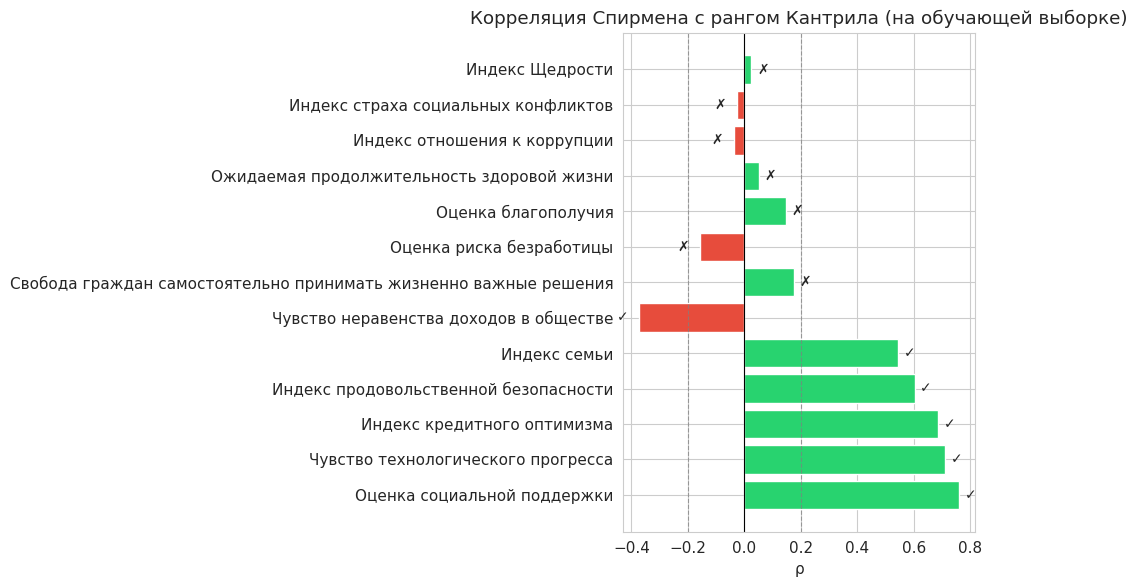

In [185]:
# 3. ВИЗУАЛИЗАЦИЯ
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#28d36f" if r > 0 else "#e74c3c" for r in corr_df["Spearman"]]
ax.barh(corr_df["Признак состояния"], corr_df["Spearman"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

# Рисуем пороги отсечения (пунктиром)
ax.axvline(
    RHO_THRESHOLD, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
)
ax.axvline(
    -RHO_THRESHOLD, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
)

for i, (_, row) in enumerate(corr_df.iterrows()):
    is_selected = (row["p-value"] < PVALUE_THRESHOLD) and (
        abs(row["Spearman"]) >= RHO_THRESHOLD
    )
    marker = "✓" if is_selected else "✗"
    if is_selected:
        print(row["Признак состояния"])
    x = row["Spearman"]
    ax.text(
        x + (0.02 if x >= 0 else -0.08), i, marker, va="center", fontsize=10
    )

ax.set_title("Корреляция Спирмена с рангом Кантрила (на обучающей выборке)")
ax.set_xlabel("ρ")
plt.tight_layout()
plt.show()


### 9. Построить модели прогноза признаков состояния по признакам причины

ПРЕДСКАЗАНИЯ ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ СОСТОЯНИЯ (RLM / OLS)

Признак 'Оценка социальной поддержки'
  Тип модели:       МНК (OLS)
  Псевдо-R²:        0.917
  Durbin-Watson:    2.007


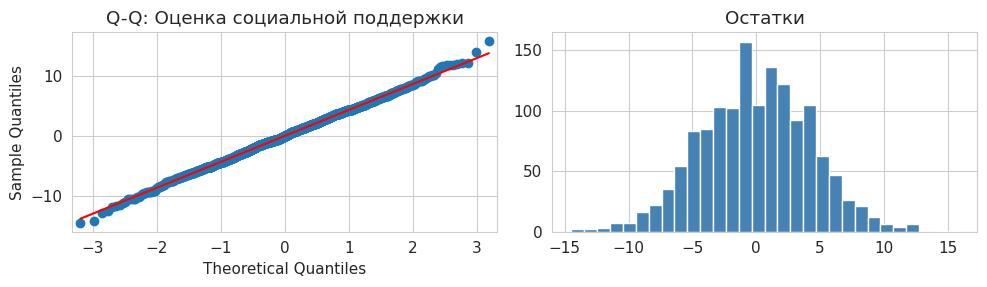


Признак 'Чувство технологического прогресса'
  Тип модели:       RLM (Штраф Хьюбера)
  Псевдо-R²:        0.886
  Durbin-Watson:    2.025


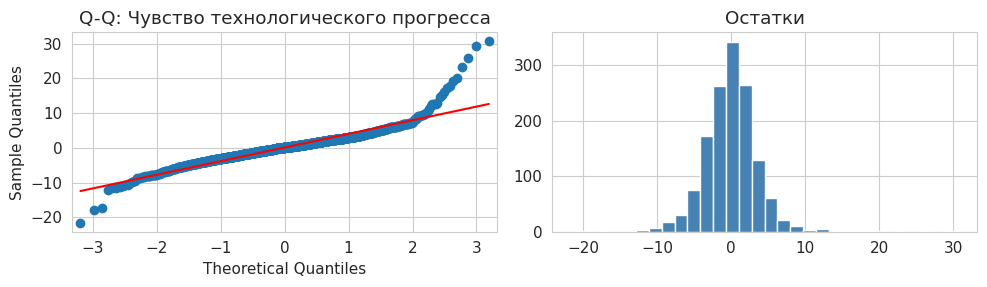


Признак 'Индекс кредитного оптимизма'
  Тип модели:       МНК (OLS)
  Псевдо-R²:        0.701
  Durbin-Watson:    2.040


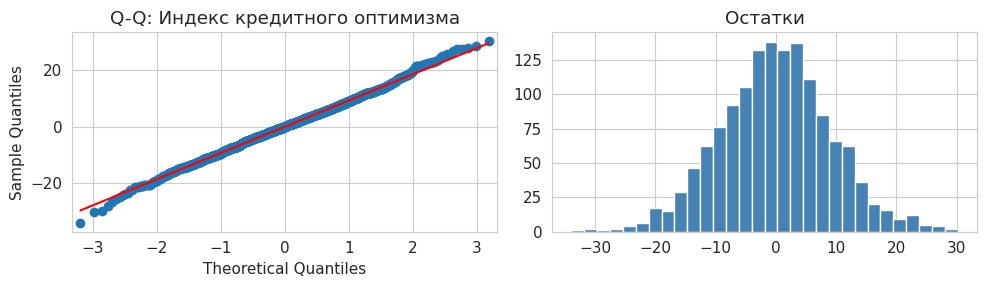


Признак 'Индекс продовольственной безопасности'
  Тип модели:       МНК (OLS)
  Псевдо-R²:        0.916
  Durbin-Watson:    2.032


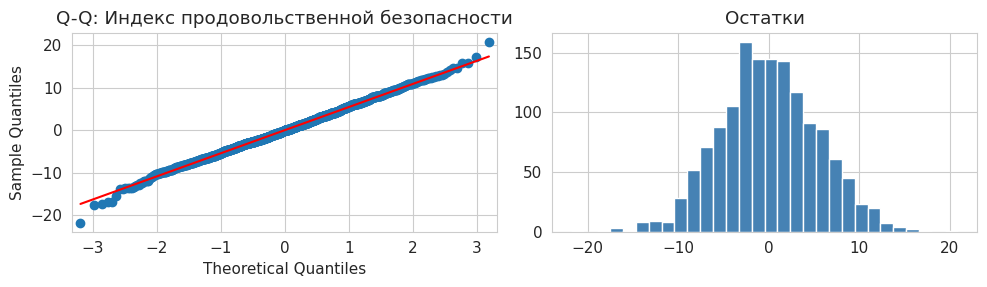


Признак 'Индекс семьи'
  Тип модели:       RLM (Штраф Хьюбера)
  Псевдо-R²:        0.497
  Durbin-Watson:    1.967


In [ ]:
ols_models = {}
ols_predictions_train = pd.DataFrame(index=df_train.index)
ols_predictions_test = pd.DataFrame(index=df_test.index)
ols_predictions_unk = pd.DataFrame(index=df_unknown.index)

print("ПРЕДСКАЗАНИЯ ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ СОСТОЯНИЯ (RLM / OLS)")

# Медианы причин считаем один раз по train
cause_medians = df_train[current_cols].median()

for target_col in selected_state:
    print(f"\n{'=' * 55}")
    print(f"Признак '{target_col}'")
    print(f"{'=' * 55}")

    # Забираем уже обученные робастные модели (вместо переобучения обычного OLS)
    model_info = ols_state_models_full[target_col]
    model = model_info["model"]
    is_robust = model_info["is_robust"]
    r2_val = model_info["rsquared"]

    ols_models[target_col] = {
        "model": model, 
        "features": current_cols,
        "rsquared": r2_val,
        "is_robust": is_robust
    }

    dw = durbin_watson(model.resid)

    print(f"  Тип модели:       {'RLM (Штраф Хьюбера)' if is_robust else 'МНК (OLS)'}")
    print(f"  Псевдо-R²:        {r2_val:.3f}")
    print(f"  Durbin-Watson:    {dw:.3f}")

    # Q-Q plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sm.qqplot(model.resid, line="s", ax=axes[0])
    axes[0].set_title(f"Q-Q: {target_col[:40]}")
    axes[1].hist(model.resid, bins=30, color="steelblue", edgecolor="white")
    axes[1].set_title("Остатки")
    plt.tight_layout()
    plt.show()

    # Формируем предсказания для всех трёх частей
    for src_df, store in [
        (df_train, ols_predictions_train),
        (df_test, ols_predictions_test),
        (df_unknown, ols_predictions_unk),
    ]:
        # Заполняем пропуски в причинах медианами train перед прогнозом
        X_filled = src_df[current_cols].fillna(cause_medians)
        Xp = sm.add_constant(X_filled, has_constant="add")
        store[target_col] = model.predict(Xp)

print(f"\nМоделей отобрано и предсказано: {len(ols_models)}")

In [ ]:
raw_residuals = model.resid
residuals = pd.Series(raw_residuals, index=df_train.index)
threshold = 2 * residuals.std()
anomalies = df_train[abs(residuals) > threshold]
print(f"Всего аномальных наблюдений: {len(anomalies)}")

for col in CAT_FEATURES:
    print(f"\n=== Анализ категориального признака: {col} ===")
    #print("Распределение во ВСЕМ датасете (доли):")
    #print(df_train[col].value_counts(normalize=True))
    
    #print("\nРаспределение ТОЛЬКО в группе аномалий (доли):")
    #print(anomalies[col].value_counts(normalize=True), end="\n\n")
    
    for job, delta in (df_train[col].value_counts(normalize=True) - anomalies[col].value_counts(normalize=True)).abs().items():
        if delta > DELTA_THRESHOLD:  # Если доля в аномалиях отличается от общей на >DELTA_THRESHOLD%
            print(f"  → Признак '{col}' с категорией '{job}' сильно представлен в аномалиях (Δ={delta:.3f})")


Всего аномальных наблюдений: 69

=== Анализ категориального признака: Сфера занятости ===
  → Признак 'Сфера занятости' с категорией 'Государственная служба' сильно представлен в аномалиях (Δ=0.045)
  → Признак 'Сфера занятости' с категорией 'Неформальная занятость' сильно представлен в аномалиях (Δ=0.048)
  → Признак 'Сфера занятости' с категорией 'Самозанятый' сильно представлен в аномалиях (Δ=0.053)


### 10. По наблюдениям с известным счастьем построить модель классификации счастья (логистическая / мультиномиальная логистическая регрессия)

Признаков для df_known (все реальные):   ['Оценка социальной поддержки', 'Чувство технологического прогресса', 'Индекс кредитного оптимизма', 'Индекс продовольственной безопасности', 'Индекс семьи', 'Чувство неравенства доходов в обществе']
Признаков для df_unknown (надежные OLS): ['Оценка социальной поддержки', 'Чувство технологического прогресса', 'Индекс кредитного оптимизма', 'Индекс продовольственной безопасности', 'Индекс семьи']

Итого признаков для классификатора (после выравнивания): 18
Fitting 10 folds for each of 5 candidates, totalling 50 fits

Лучшие параметры: {'classifier__C': 0.5, 'classifier__penalty': 'l2'}
CV micro precision (train): 0.515

Micro Precision (test): 0.514  (критерий: > 0.6)
Критерий НЕ выполнен ✗

Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.83      0.68        54
           1       0.67      0.47      0.55        55
           2       0.41      0.29      0.34        69
           3      

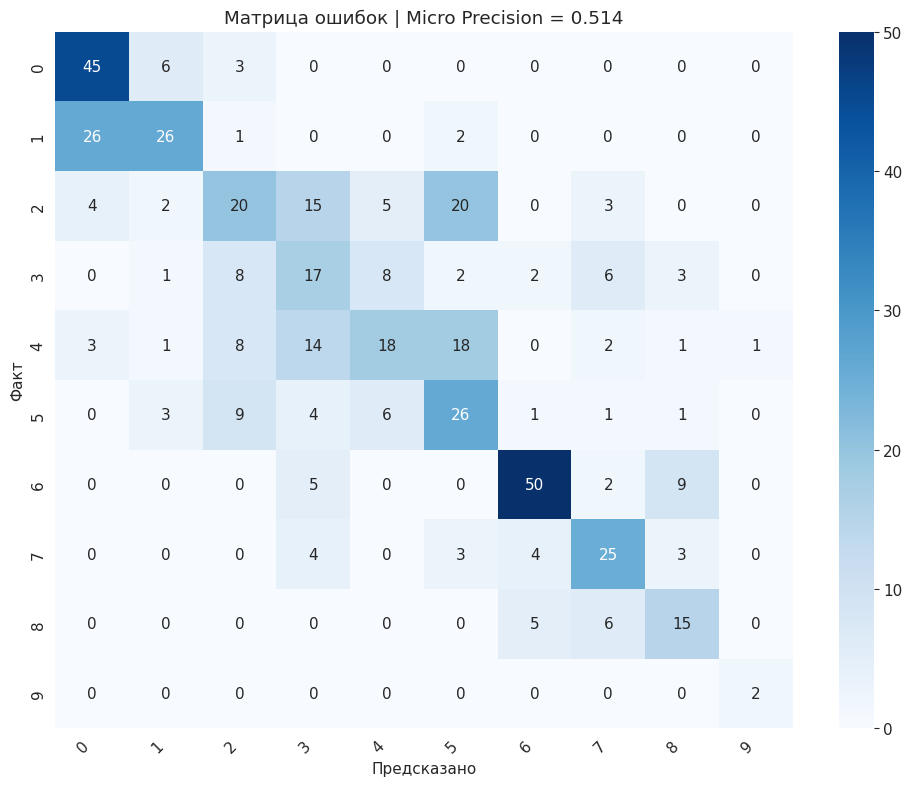

In [ ]:
# ─── ФИНАЛЬНЫЕ ПРИЗНАКИ ───────────────────────────────────────────
# ИСПРАВЛЕНИЕ ОШИБКИ И ОТБОР НАДЕЖНЫХ СОСТОЯНИЙ ДЛЯ UNKNOWN
# Теперь обращаемся напрямую к ключу "rsquared", где сохранен Псевдо-R² для RLM
final_states = [
    col
    for col in selected_state
    if col in ols_models and ols_models[col]["rsquared"] >= R2_THRESHOLD
]

print("Признаков для df_known (все реальные):  ", selected_state)
print("Признаков для df_unknown (надежные RLM/OLS):", final_states)

# =====================================================================
# РАСЧЕТ МЕДИАН (СТРОГО НА TRAIN ДЛЯ ИСКЛЮЧЕНИЯ УТЕЧЕК)
# =====================================================================
cause_medians = df_train[current_cols].median()
real_state_medians_train = df_train[selected_state].median()

# =====================================================================
# ГЕНЕРАЦИЯ ПРЕДСКАЗАНИЙ OLS ДЛЯ СКРЫТОЙ ВЫБОРКИ (UNKNOWN)
# =====================================================================
ols_predictions_train = pd.DataFrame(index=df_train.index)
ols_predictions_test = pd.DataFrame(index=df_test.index)
ols_predictions_unk = pd.DataFrame(index=df_unknown.index)

for state_col in final_states:
    model = ols_models[state_col]["model"]
    
    X_tr = sm.add_constant(df_train[current_cols])
    ols_predictions_train[state_col] = model.predict(X_tr)

    X_te = sm.add_constant(df_test[current_cols])
    ols_predictions_test[state_col] = model.predict(X_te)

    X_un = sm.add_constant(df_unknown[current_cols])
    ols_predictions_unk[state_col] = model.predict(X_un)

# Расчет медиан для OLS-прогнозов
state_medians_ols = ols_predictions_train[final_states].median()

# =====================================================================
# УНИВЕРСАЛЬНАЯ ФУНКЦИЯ СБОРКИ МАТРИЦ ПРИЗНАКОВ (build_X)
# =====================================================================
def build_X(source_df, use_ols_predictions=False, ols_preds_df=None, train_cols=None):
    """
    Универсальный конвейер: Причины + Состояния (Реальные ИЛИ Прогнозы) + Категории.
    Выравнивает структуру колонок относительно обучающей выборки.
    """
    # 1. Причины (VIF признаки)
    X_c = source_df[current_cols].fillna(cause_medians).reset_index(drop=True)
    
    # 2. Признаки состояний (Переключение по флагу методологии)
    if use_ols_predictions:
        # Для скрытой выборки (unknown) берем только надежные OLS-предсказания
        X_s = ols_preds_df[final_states].fillna(state_medians_ols).reset_index(drop=True)
    else:
    # Для известных данных (train/test) берем НАСТОЯЩИЕ чистые значения из датасета
        X_s = source_df[selected_state].fillna(real_state_medians_train).reset_index(drop=True)
    
    # 3. Категориальные переменные
    X_cat = pd.get_dummies(source_df[CAT_FEATURES].reset_index(drop=True), drop_first=True)
    
    # Объединяем блоки в итоговую матрицу
    X_res = pd.concat([X_c, X_s, X_cat], axis=1)
    
    # 4. Жесткое выравнивание признаков по тренировочной матрице
    if train_cols is not None:
        for col in set(train_cols) - set(X_res.columns):
            X_res[col] = 0
        X_res = X_res[train_cols]
        
    return X_res

# Сборка финальных датасетов
X_clf_train = build_X(df_train, use_ols_predictions=True, ols_preds_df=ols_predictions_train)
train_columns = X_clf_train.columns.tolist()

X_clf_test  = build_X(df_test, use_ols_predictions=True, ols_preds_df=ols_predictions_test, train_cols=train_columns)
X_clf_unk   = build_X(df_unknown, use_ols_predictions=True, ols_preds_df=ols_predictions_unk, train_cols=train_columns)

print(f"\nИтого признаков для классификатора (после выравнивания): {X_clf_train.shape[1]}")


# ─── КЛАССИФИКАТОР ────────────────────────────────────────────────
y_train_labels = y_train.values
y_test_labels  = y_test.values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        random_state=100,
        class_weight=None,  # Без искусственных весов для точности Micro Precision
    )),
])

# Расширяем сетку параметров для поиска оптимальной силы регуляризации
param_grid = {
    "classifier__C":            [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    "classifier__penalty":      ["l2"],
}

grid_search = GridSearchCV(
    pipe, param_grid,
    cv=cv,
    scoring="precision_micro",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_clf_train, y_train_labels)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"CV micro precision (train): {grid_search.best_score_:.3f}")

clf_pipeline   = grid_search.best_estimator_
y_pred_labels  = clf_pipeline.predict(X_clf_test)

micro_prec = precision_score(
    y_test_labels, y_pred_labels,
    average="micro",
    labels=sorted(set(y_test_labels) | set(y_pred_labels)),
)
print(f"\nMicro Precision (test): {micro_prec:.3f}  (критерий: > 0.6)")
print("Критерий", "ВЫПОЛНЕН ✓" if micro_prec > 0.6 else "НЕ выполнен ✗")

actual_test_classes = sorted(list(set(y_test_labels)))
print("\nClassification Report:\n")
print(
    classification_report(
        y_test_labels,
        y_pred_labels,
        labels=actual_test_classes,
        zero_division=0,
    )
)

# Визуализация матрицы ошибок
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=actual_test_classes)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actual_test_classes,
    yticklabels=actual_test_classes,
    ax=ax,
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Факт")
ax.set_title(f"Матрица ошибок | Micro Precision = {micro_prec:.3f}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 12. Спрогнозировать неизвестные значения счастья

In [ ]:
df_unknown_predicted = df_unknown.copy()

# Передаем данные в pipeline (он сам масштабирует)
df_unknown_predicted["Predicted_Happiness"] = clf_pipeline.predict(X_clf_unk)

# Обратно декодируем числа классов в текстовые метки
rank_to_class = {i: cls for i, cls in enumerate(actual_classes)}
df_unknown_predicted["Predicted_Class"] = df_unknown_predicted[
    "Predicted_Happiness"
].map(rank_to_class)

# Предсказываем вероятности
probs = clf_pipeline.predict_proba(X_clf_unk)

# Добавляем вероятности в датафрейм
for i, class_idx in enumerate(clf_pipeline.named_steps["classifier"].classes_):
    class_name = rank_to_class.get(class_idx, f"Class_{class_idx}")
    df_unknown_predicted[f"Prob_{class_name}"] = np.round(probs[:, i], 3)

print("--- Распределение предсказанных групп ---")
print(df_unknown_predicted["Predicted_Class"].value_counts(dropna=False))

print("\n--- Первые 5 строк с прогнозами ---")
prob_cols = [
    col for col in df_unknown_predicted.columns if col.startswith("Prob_")
]
cols_to_show = [CANTRIL_COL, "Predicted_Class"] + prob_cols

display(df_unknown_predicted[cols_to_show].head())

--- Распределение предсказанных групп ---
Predicted_Class
Suffering     118
Doing well     96
Hopeless       75
Just ok        66
Coping         63
Depressed      58
Strugglng      53
Blooming       42
Thriving       26
Prospering      3
Name: count, dtype: int64

--- Первые 5 строк с прогнозами ---


,Ощущаемое счастье,Predicted_Class,Prob_Hopeless,Prob_Depressed,Prob_Suffering,Prob_Strugglng,Prob_Coping,Prob_Just ok,Prob_Doing well,Prob_Blooming,Prob_Thriving,Prob_Prospering
10,Неизвестно,Doing well,0.000,0.000,0.007,0.016,0.003,0.005,0.771,0.101,0.098,0.0
11,Неизвестно,Coping,0.001,0.002,0.232,0.252,0.401,0.091,0.001,0.020,0.000,0.0
20,Неизвестно,Doing well,0.000,0.000,0.029,0.071,0.128,0.153,0.279,0.120,0.221,0.0
22,Неизвестно,Suffering,0.001,0.001,0.379,0.194,0.201,0.189,0.002,0.033,0.000,0.0
24,Неизвестно,Doing well,0.000,0.000,0.001,0.006,0.001,0.000,0.631,0.005,0.356,0.0


In [ ]:
# 1. Какие модели в ols_state_models_full и их R²
for col, info in ols_state_models_full.items():
    print(f"{col}: is_robust={info['is_robust']}, R²={info['rsquared']:.3f}")

# 2. Какие модели в ols_models (из Cell 28) и их R²  
for col, info in ols_models.items():
    print(f"{col}: R²={info['model'].rsquared:.3f}")

Оценка благополучия: is_robust=False, R²=0.047
Оценка социальной поддержки: is_robust=False, R²=0.917
Ожидаемая продолжительность здоровой жизни: is_robust=False, R²=0.020
Свобода граждан самостоятельно принимать жизненно важные решения: is_robust=False, R²=0.090
Индекс Щедрости: is_robust=False, R²=0.013
Индекс отношения к коррупции: is_robust=True, R²=0.053
Оценка риска безработицы: is_robust=False, R²=0.055
Индекс кредитного оптимизма: is_robust=False, R²=0.701
Индекс страха социальных конфликтов: is_robust=False, R²=0.006
Индекс семьи: is_robust=True, R²=0.497
Индекс продовольственной безопасности: is_robust=False, R²=0.916
Чувство технологического прогресса: is_robust=True, R²=0.886
Чувство неравенства доходов в обществе: is_robust=False, R²=0.183
Оценка социальной поддержки: R²=0.917
Чувство технологического прогресса: R²=0.886
Индекс кредитного оптимизма: R²=0.701
Индекс продовольственной безопасности: R²=0.916
Индекс семьи: R²=0.497
Чувство неравенства доходов в обществе: R²=0.